<a href="https://colab.research.google.com/github/sharvmahajan/TE/blob/DSBDAL/A4/DSBDAL_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#DSBDAL Assignment 4

Name: Sharv Mahajan

Roll No. : 31430

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###Loading Dataset

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###Basic Initial Survey

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


##Data Cleaning
### Handling Missing Values

- Age → filled using median

- Embarked → filled using mode

In [4]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

## Survival Stats

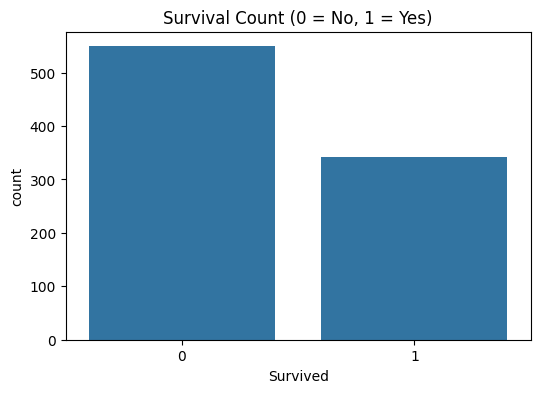

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)

plt.title("Survival Count (0 = No, 1 = Yes)")
plt.show()

### Relationship between Cabin/Deck and Survival

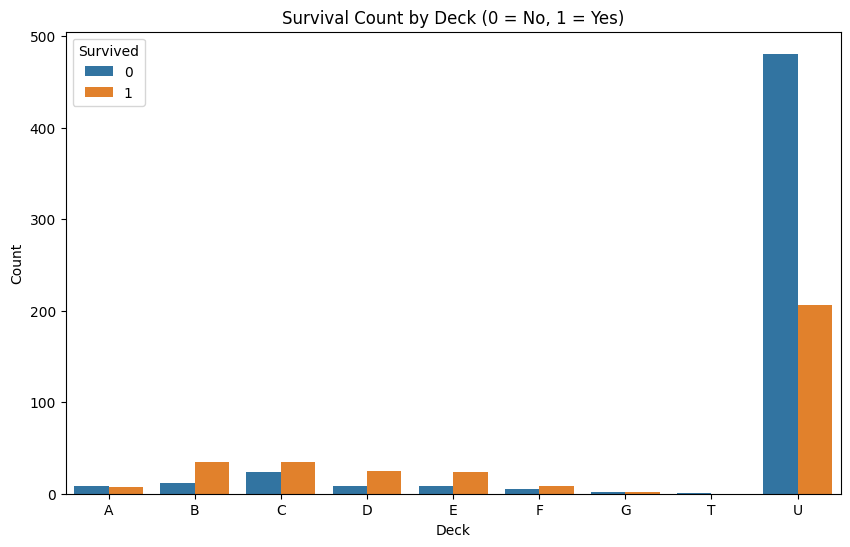

In [6]:
df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
plt.figure(figsize=(10, 6))
sns.countplot(x='Deck', hue='Survived', data=df, order=['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T', 'U'])
plt.title('Survival Count by Deck (0 = No, 1 = Yes)')
plt.xlabel('Deck')
plt.ylabel('Count')
plt.show()

### Relationship between Age and Survival

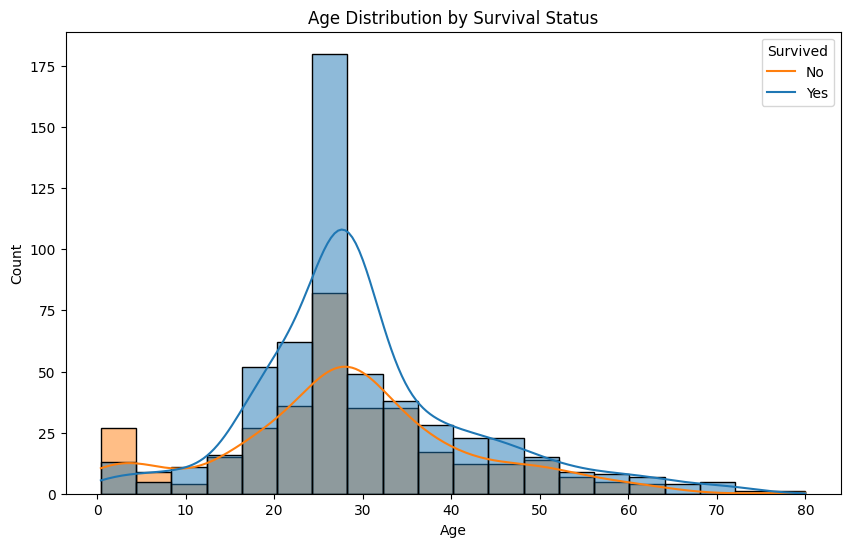

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=20)
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

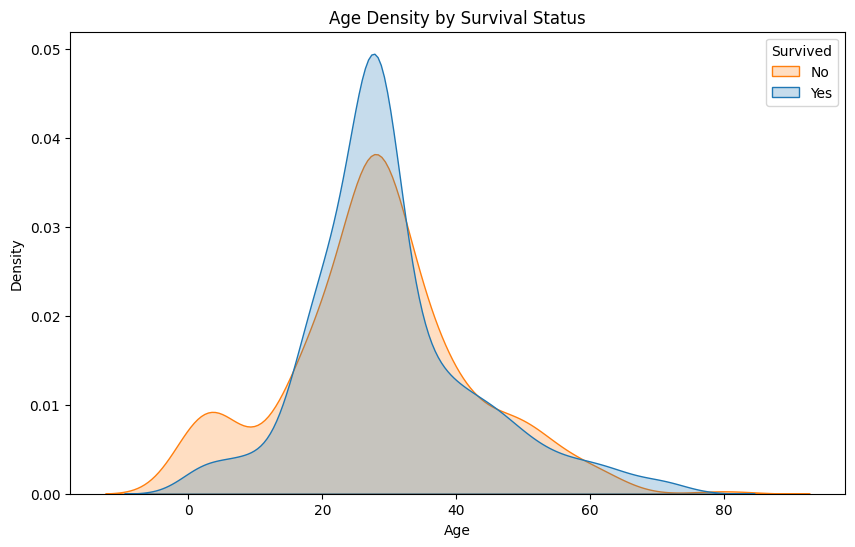

In [8]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Age', hue='Survived', fill=True, common_norm=False)
plt.title('Age Density by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

In [9]:
average_fare_by_survival = df.groupby('Survived')['Fare'].mean()
print("Average Fare by Survival Status (0 = Non-Survivor, 1 = Survivor):\n")
print(average_fare_by_survival)

Average Fare by Survival Status (0 = Non-Survivor, 1 = Survivor):

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64


We can also visualize this difference using a bar plot.

/tmp/ipython-input-918435204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_fare_by_survival.index, y=average_fare_by_survival.values, palette='viridis')


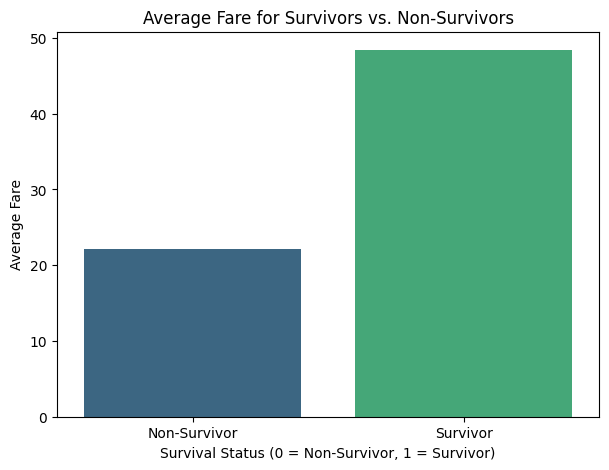

In [10]:
plt.figure(figsize=(7,5))
sns.barplot(x=average_fare_by_survival.index, y=average_fare_by_survival.values, palette='viridis')
plt.title('Average Fare for Survivors vs. Non-Survivors')
plt.xlabel('Survival Status (0 = Non-Survivor, 1 = Survivor)')
plt.ylabel('Average Fare')
plt.xticks(ticks=[0, 1], labels=['Non-Survivor', 'Survivor'])
plt.show()

### Survival Rate by Gender

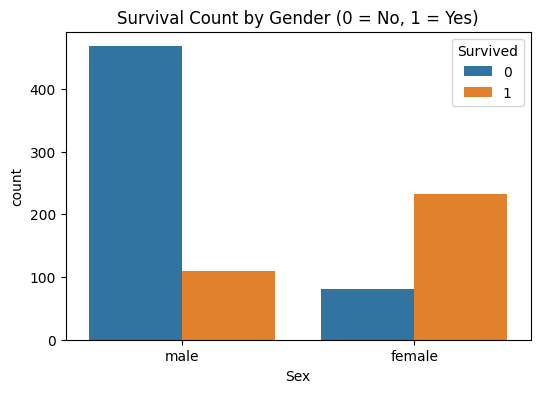

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender (0 = No, 1 = Yes)')
plt.show()

### Survival Rate by Passenger Class (Pclass)

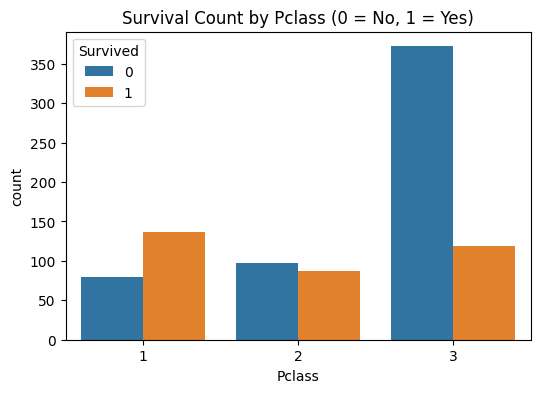

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Pclass (0 = No, 1 = Yes)')
plt.show()

### Survival Rate by Embarked Port

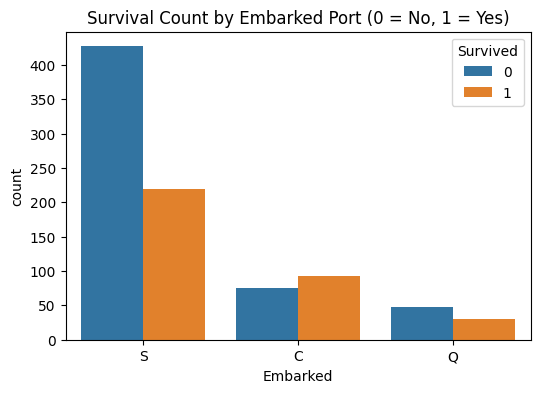

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival Count by Embarked Port (0 = No, 1 = Yes)')
plt.show()

## Summary


*   **Missing Data Handled**: We
successfully imputed missing 'Age' values with the median and 'Embarked' values with the mode, allowing for more complete analysis.
*   **Survival Disparities**: Overall, a significant portion of passengers did not survive. However, survival rates were not uniform across all groups.

* **Gender Bias**: Females had a substantially higher survival rate than males, suggesting a 'women and children first' protocol was largely followed.
* **Survival Disparities**: Overall, a significant portion of passengers did not survive. However, survival rates were not uniform across all groups.
  Socio-Economic Impact (Pclass & Fare): Passengers in higher classes (Pclass 1) and those who paid higher fares exhibited considerably better survival chances. This implies that economic status and potentially cabin location (which often correlated with class) played a crucial role.
* **Age-Related Survival**: Very young children (0-10 years) showed a relatively higher survival rate. Conversely, there was a high fatality rate among young adults (20-40 years).
  
* **Cabin/Deck Significance**: Extracting the 'Deck' from 'Cabin' revealed a strong correlation with survival. Passengers assigned to certain decks (A, B, C, D, E) had better survival rates than those whose cabin information was unknown ('U'), reinforcing the class/location advantage.

* **Embarkation Port Variation** : There were noticeable differences in survival rates depending on the port of embarkation, with passengers from Cherbourg (C) showing a comparatively higher survival rate.

In essence, factors like gender, socio-economic status (indicated by Pclass and Fare), age, and cabin location were strong determinants of survival on the Titanic. These insights provide a foundational understanding of the survival patterns in the dataset.